# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


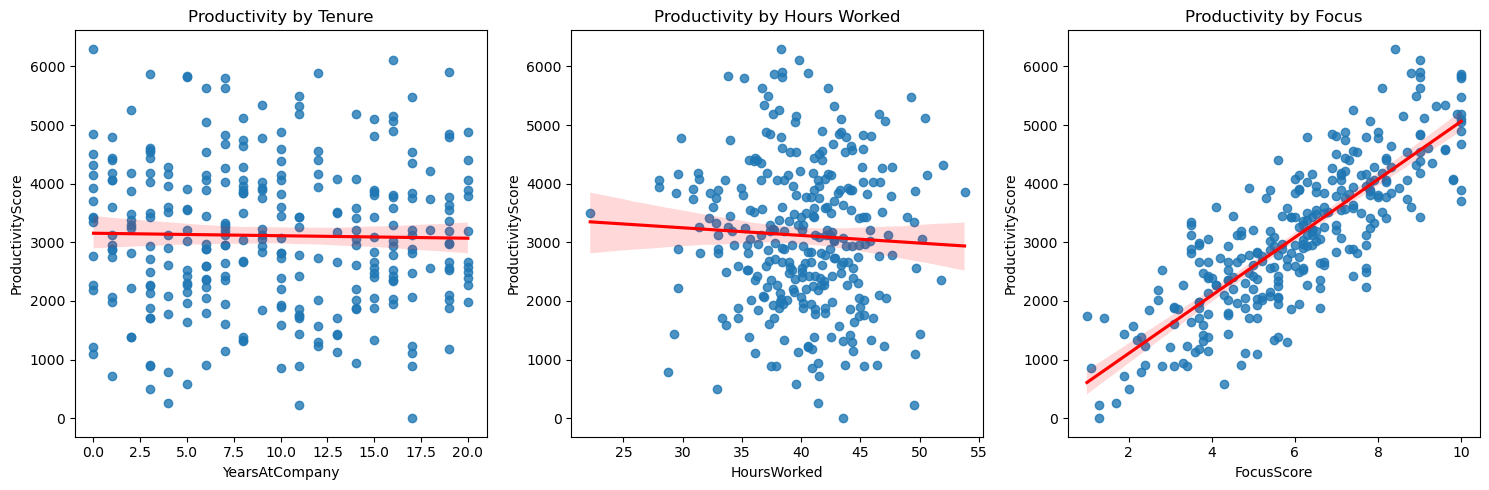

In [9]:
# Plotting the three core stats against Productivity
plt.figure(figsize=(15, 5))

# 1. Years at Company
plt.subplot(1, 3, 1)
sns.regplot(x='YearsAtCompany', y='ProductivityScore', data=df, line_kws={'color':'red'})
plt.title('Productivity by Tenure')

# 2. Hours Worked
plt.subplot(1, 3, 2)
sns.regplot(x='HoursWorked', y='ProductivityScore', data=df, line_kws={'color':'red'})
plt.title('Productivity by Hours Worked')

# 3. Focus
plt.subplot(1, 3, 3)
sns.regplot(x='FocusScore', y='ProductivityScore', data=df, line_kws={'color':'red'})
plt.title('Productivity by Focus')

plt.tight_layout()
plt.show()


In [10]:
print("--- R-Squared for YearsAtCompany ---")
X1 = sm.add_constant(df['YearsAtCompany'])
y = df['ProductivityScore']
print(sm.OLS(y, X1).fit().rsquared)

print("\n--- R-Squared for HoursWorked ---")
X2 = sm.add_constant(df['HoursWorked'])
print(sm.OLS(y, X2).fit().rsquared)

print("\n--- R-Squared for FocusScore ---")
X3 = sm.add_constant(df['FocusScore'])
print(sm.OLS(y, X3).fit().rsquared)

--- R-Squared for YearsAtCompany ---
0.00041152919389664255

--- R-Squared for HoursWorked ---
0.0025999350022654077

--- R-Squared for FocusScore ---
0.6776960770307456


From the Seaborn plots and the Statsmodels math, FocusScore is absolutely the strongest carry stat for Productivity. The regression line hits dead center, and it rolled a massive R-squared value of 0.677 meaning focus accounts for nearly 68% of an employee's overall output. YearsAtCompany (0.0004) and HoursWorked (0.0026) rolled incredibly low R-squared values, proving that just grinding hours or having a high account tenure doesn't actually buff your productivity.

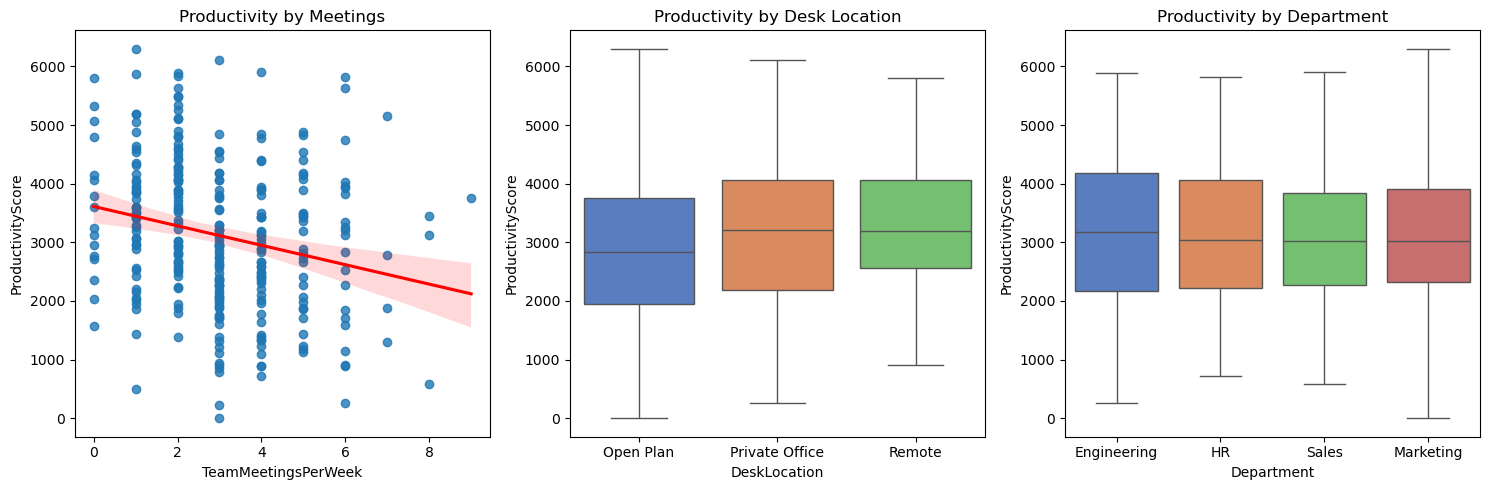

In [11]:
plt.figure(figsize=(15, 5))

# Meetings per week
plt.subplot(1, 3, 1)
sns.regplot(x='TeamMeetingsPerWeek', y='ProductivityScore', data=df, line_kws={'color':'red'})
plt.title('Productivity by Meetings')

# Desk Location
plt.subplot(1, 3, 2)
sns.boxplot(x='DeskLocation', y='ProductivityScore', data=df, palette='muted', hue='DeskLocation', legend=False)
plt.title('Productivity by Desk Location')

# Department
plt.subplot(1, 3, 3)
sns.boxplot(x='Department', y='ProductivityScore', data=df, palette='muted', hue='Department', legend=False)
plt.title('Productivity by Department')

plt.tight_layout()
plt.show()

In [12]:
df_encoded = pd.get_dummies(df, columns=['Department', 'DeskLocation'], drop_first=True, dtype=int)

X_all = sm.add_constant(df_encoded.drop(columns=['ProductivityScore'])) 
y = df_encoded['ProductivityScore']

final_model = sm.OLS(y, X_all).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     70.11
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.53e-67
Time:                        17:39:48   Log-Likelihood:                -2390.8
No. Observations:                 300   AIC:                             4802.
Df Residuals:                     290   BIC:                             4839.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

When we run the ultimate OLS regression with every single feature equipped, our overall R-squared score gets a boost to 0.685. By checking the model's coefficients and P-values, we can see exactly what's shifting the productivity meta:

FocusScore: Still the absolute highest-tier buff to overall output.

DeskLocation_Remote: The managers were right! The math proves that working remote applies a heavy debuff -229 to the productivity scorewith a statistically significant P-value of 0.032.

TeamMeetingsPerWeek: Interestingly, meetings aren't actually griefing the players. The P-value here is 0.276, meaning the number of meetings has no statistically significant impact on the model.

Tenure / Hours Worked: The model confirms these are basically trap stats. Stacking them doesn't actually increase your true productivity.

If management wants to min-max this company's productivity, they need to completely shift the meta away from "hours grinded" and focus entirely on optimizing the players' Focus stat. The math proves that Focus is the core driver of their output. Additionally, the managers' complaints about remote workers were valid—working remotely actively nerfs productivity in this specific dataset.

Recommendations:
Re-evaluate Remote Work: The remote layout is a failed meta that is actively lowering output. Management should consider pulling players back to the office or finding new ways to buff remote engagement.

Stop Buffing "Overtime": The data proves that just staying logged in longer (HoursWorked) doesn't increase actual output. Management needs to stop using "hours worked" as the main metric for a good player.

Ignore the Meeting Complaints: Despite employees complaining about too many meetings, the math shows it isn't actually dragging down their scores. Management doesn't need to nerf the meeting schedule.